In [1]:
import os
import sys
# Ensure project root is on sys.path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
# Project root ensured on sys.path

In [2]:
# Imports and utilities
from typing import Dict
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader

from model_classes.gnn import create_gnn
from data_loaders.landmark_graph_data_loader import LandmarksGraphDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

/home/quiet98k/Code/Fall25/hand-gestures-classifier/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [3]:
# Create datasets and dataloaders (graph data)
torch.manual_seed(42)

annotations_root = os.path.join(PROJECT_ROOT, 'data', 'annotations')
train_ds = LandmarksGraphDataset(annotations_root=annotations_root, split='train')
val_ds = LandmarksGraphDataset(annotations_root=annotations_root, split='val')

# Infer dimensions from dataset
in_channels = train_ds.num_node_features
num_classes = train_ds.num_classes

print('Dataset sizes: train=', len(train_ds), 'val=', len(val_ds))
print('Node features:', in_channels, 'Num classes:', num_classes)

# DataLoaders (PyG DataLoader)
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

# Quick smoke test
batch = next(iter(train_loader))
print(f'Batch: {batch}')
print(f'Batch x shape: {batch.x.shape}, edge_index shape: {batch.edge_index.shape}, y shape: {batch.y.shape}')

Dataset sizes: train= 408237 val= 53392
Node features: 2 Num classes: 18
Batch: DataBatch(x=[1344, 2], edge_index=[2, 2944], y=[64], bbox=[256], label_str=[64], batch=[1344], ptr=[65])
Batch x shape: torch.Size([1344, 2]), edge_index shape: torch.Size([2, 2944]), y shape: torch.Size([64])


In [4]:
# Training and evaluation helpers (graph input)
def train_epoch(model: nn.Module, loader: DataLoader, optimizer, criterion) -> Dict[str, float]:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(logits, batch.y)
        loss.backward()
        optimizer.step()
        bsz = batch.y.size(0)
        total_loss += loss.item() * bsz
        preds = logits.argmax(dim=1)
        total_correct += (preds == batch.y).sum().item()
        total += bsz
    return {'loss': total_loss / total, 'acc': total_correct / total}

def evaluate(model: nn.Module, loader: DataLoader, criterion) -> Dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(logits, batch.y)
            total_loss += loss.item() * batch.y.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == batch.y).sum().item()
            total += batch.y.size(0)
    return {'loss': total_loss / total, 'acc': total_correct / total}

In [5]:
# Fixed hyperparameter training (single configuration)
final_models_dir = os.path.join(PROJECT_ROOT, 'final_models')
os.makedirs(final_models_dir, exist_ok=True)

# Hyperparams
lr = 1e-3
hidden_channels = 64
num_layers = 3
dropout = 0.1
activation = 'relu'
mlp_hidden = 64
batch_size = 64
max_epochs = 8
eval_interval = 500  # Evaluate every N training steps
criterion = nn.CrossEntropyLoss()

# Build model and loaders
model = create_gnn(
    in_channels=in_channels,
    num_classes=num_classes,
    hidden_channels=hidden_channels,
    num_layers=num_layers,
    dropout=dropout,
    activation=activation,
    mlp_hidden=mlp_hidden,
)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

best_val_acc = 0.0
best_state = None
history = {'step': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
global_step = 0

for epoch in range(1, max_epochs + 1):
    model.train()
    epoch_loss = 0.0
    epoch_correct = 0
    epoch_total = 0
    
    for batch_idx, batch in enumerate(train_loader, start=1):
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(logits, batch.y)
        loss.backward()
        optimizer.step()
        
        bsz = batch.y.size(0)
        epoch_loss += loss.item() * bsz
        preds = logits.argmax(dim=1)
        epoch_correct += (preds == batch.y).sum().item()
        epoch_total += bsz
        global_step += 1
        
        # Intra-epoch evaluation
        if global_step % eval_interval == 0:
            train_loss = epoch_loss / epoch_total
            train_acc = epoch_correct / epoch_total
            va = evaluate(model, val_loader, criterion)
            history['step'].append(global_step)
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(va['loss'])
            history['val_acc'].append(va['acc'])
            print(f'Step {global_step} (Epoch {epoch}) | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={va["loss"]:.4f} val_acc={va["acc"]:.4f}')
            if va['acc'] > best_val_acc:
                best_val_acc = va['acc']
                best_state = {'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(), 'epoch': epoch, 'step': global_step}
            model.train()
    
    # End of epoch evaluation
    train_loss = epoch_loss / epoch_total
    train_acc = epoch_correct / epoch_total
    va = evaluate(model, val_loader, criterion)
    print(f'Epoch {epoch}/{max_epochs} END | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={va["loss"]:.4f} val_acc={va["acc"]:.4f}')
    if va['acc'] > best_val_acc:
        best_val_acc = va['acc']
        best_state = {'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(), 'epoch': epoch, 'step': global_step}

# Persist best
out_path = os.path.join(final_models_dir, 'gnn.pth')
if best_state is not None:
    torch.save({
        'config': {
            'lr': lr,
            'hidden_channels': hidden_channels,
            'num_layers': num_layers,
            'dropout': dropout,
            'activation': activation,
            'mlp_hidden': mlp_hidden,
            'batch_size': batch_size,
            'max_epochs': max_epochs,
        },
        'best_val_acc': best_val_acc,
        'state': best_state,
    }, out_path)
    
    # Write/update combined metadata JSON
    meta_entry = {
        'model_type': 'gnn',
        'data_type': 'landmarks_graph',
        'in_channels': in_channels,
        'num_classes': num_classes,
        'hidden_channels': hidden_channels,
        'num_layers': num_layers,
        'dropout': dropout,
        'activation': activation,
        'mlp_hidden': mlp_hidden,
        'training': {'lr': lr, 'batch_size': batch_size, 'max_epochs': max_epochs},
        'best_val_acc': best_val_acc,
        'checkpoint_path': out_path,
    }
    combined_meta_path = os.path.join(final_models_dir, 'models_metadata.json')
    try:
        import json
        combined = {}
        if os.path.exists(combined_meta_path):
            with open(combined_meta_path, 'r') as cf:
                try:
                    combined = json.load(cf)
                except Exception:
                    combined = {}
        combined['gnn'] = meta_entry
        with open(combined_meta_path, 'w') as cf:
            json.dump(combined, cf, indent=2)
    except Exception as _e:
        print('Warning: failed to write combined metadata file', _e)

# Build single-best record for downstream cells
best = {
    'config': {
        'lr': lr,
        'hidden_channels': hidden_channels,
        'num_layers': num_layers,
        'dropout': dropout,
        'activation': activation,
        'mlp_hidden': mlp_hidden,
        'batch_size': batch_size,
        'max_epochs': max_epochs,
    },
    'best_val_acc': best_val_acc,
    'path': out_path,
    'history': history,
}

Step 500 (Epoch 1) | train_loss=1.2408 train_acc=0.6542 | val_loss=0.6319 val_acc=0.8376
Step 1000 (Epoch 1) | train_loss=0.9374 train_acc=0.7341 | val_loss=0.3933 val_acc=0.8928
Step 1500 (Epoch 1) | train_loss=0.7817 train_acc=0.7751 | val_loss=0.2917 val_acc=0.9210
Step 2000 (Epoch 1) | train_loss=0.6878 train_acc=0.8009 | val_loss=0.2574 val_acc=0.9245
Step 2500 (Epoch 1) | train_loss=0.6256 train_acc=0.8182 | val_loss=0.2247 val_acc=0.9342
Step 3000 (Epoch 1) | train_loss=0.5780 train_acc=0.8309 | val_loss=0.2219 val_acc=0.9360
Step 3500 (Epoch 1) | train_loss=0.5412 train_acc=0.8408 | val_loss=0.1948 val_acc=0.9422
Step 4000 (Epoch 1) | train_loss=0.5113 train_acc=0.8492 | val_loss=0.1781 val_acc=0.9491
Step 4500 (Epoch 1) | train_loss=0.4866 train_acc=0.8562 | val_loss=0.1828 val_acc=0.9466
Step 5000 (Epoch 1) | train_loss=0.4658 train_acc=0.8619 | val_loss=0.1661 val_acc=0.9505
Step 5500 (Epoch 1) | train_loss=0.4477 train_acc=0.8670 | val_loss=0.1666 val_acc=0.9526
Step 6000 (

In [6]:
# Load best model and run a quick inference check
print(f"Best config: {best['config']} val_acc={best['best_val_acc']}")
ckpt = torch.load(best['path'], map_location=device)
cfg = ckpt['config']
model = create_gnn(
    in_channels=in_channels,
    num_classes=num_classes,
    hidden_channels=cfg['hidden_channels'],
    num_layers=cfg['num_layers'],
    dropout=cfg['dropout'],
    activation=cfg['activation'],
    mlp_hidden=cfg['mlp_hidden'],
)
model.load_state_dict(ckpt['state']['model_state'])
model = model.to(device).eval()

batch = next(iter(val_loader))
batch = batch.to(device)
with torch.no_grad():
    logits = model(batch.x, batch.edge_index, batch.batch)
    preds = logits.argmax(dim=1).cpu()
print(f"Sample preds: {preds[:10].tolist()}")
print(f"Sample labels: {batch.y[:10].cpu().tolist()}")

Best config: {'lr': 0.001, 'hidden_channels': 64, 'num_layers': 3, 'dropout': 0.1, 'activation': 'relu', 'mlp_hidden': 64, 'batch_size': 64, 'max_epochs': 8} val_acc=0.9769815702727
Sample preds: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Sample labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


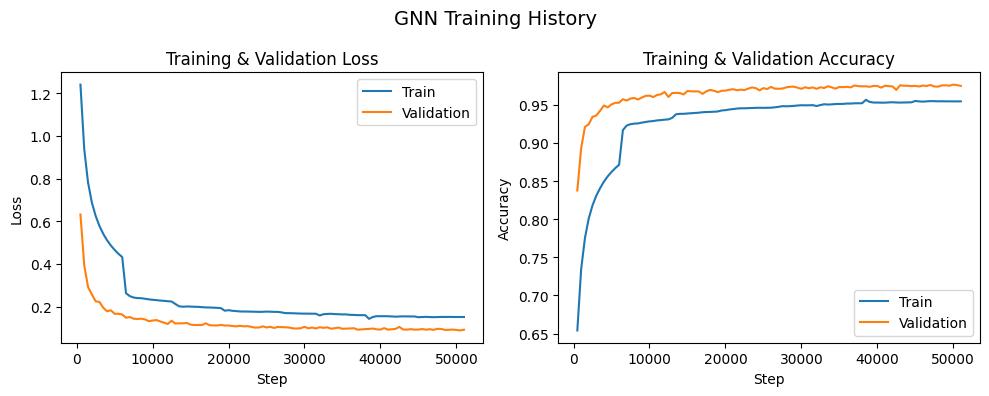

Saved plot to /home/quiet98k/Code/Fall25/hand-gestures-classifier/graphs/gnn_training_history.png


In [7]:
# Plot training/validation history for the best config
import matplotlib.pyplot as plt

# Ensure graphs directory exists
graphs_dir = os.path.join(PROJECT_ROOT, 'graphs')
os.makedirs(graphs_dir, exist_ok=True)

hist = best.get('history')
if hist is None or not hist.get('step'):
    print('No history available for best config')
else:
    steps = hist['step']
    fig = plt.figure(figsize=(10, 4))
    fig.suptitle('GNN Training History', fontsize=14)
    
    plt.subplot(1, 2, 1)
    plt.plot(steps, hist['train_loss'], label='Train')
    plt.plot(steps, hist['val_loss'], label='Validation')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(steps, hist['train_acc'], label='Train')
    plt.plot(steps, hist['val_acc'], label='Validation')
    plt.xlabel('Step')
    plt.ylabel('Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(graphs_dir, 'gnn_training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved plot to {graphs_dir}/gnn_training_history.png')